<a href="https://colab.research.google.com/github/adityab-tech/DC/blob/main/DC1_adi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#KNN Classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df=pd.read_csv('/content/KNNAlgorithmDataset.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.shape

(569, 33)

In [7]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [8]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [9]:
df.drop(columns='Unnamed: 32',inplace=True)

In [10]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0})

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [14]:
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        # Calculate distance from every training point
        distances = []
        for i in range(len(X_train)):
            distance = euclidean_distance(test_point,X_train[i])
            distances.append((distance, y_train.iloc[i]))

        distances.sort(key=lambda x: x[0])                         # sort by dist
        nearest = distances[:k]                                    # get knn
        labels = [label for distance, label in nearest]            # get labels
        prediction = max(set(labels), key=labels.count)            # majority voting
        predictions.append(prediction)
    return np.array(predictions)


In [15]:
k = 5
y_pred = knn_predict(X_train,y_train,X_test,k)

In [16]:
print("K =", k)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

K = 5
Accuracy: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



#Minimum Distance Classifier

In [17]:
# centroid of class 0 (benign and maligant)
centroid_0 = X_train[y_train.values == 0].mean(axis=0)
centroid_1 = X_train[y_train.values == 1].mean(axis=0)

In [18]:
def minimum_distance_classifier(X_test, centroid_0, centroid_1):
    predictions = []
    for x in X_test:
        # dist from class 0 and 1 centroid
        distance_0 = np.sqrt(np.sum((x - centroid_0) ** 2))
        distance_1 = np.sqrt(np.sum((x - centroid_1) ** 2))
        # nearest centriod
        if distance_0 < distance_1:
            predictions.append(0)
        else:
            predictions.append(1)
    return np.array(predictions)

In [19]:
y_pred = minimum_distance_classifier(X_test,centroid_0,centroid_1)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9210526315789473

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        72
           1       0.97      0.81      0.88        42

    accuracy                           0.92       114
   macro avg       0.94      0.90      0.91       114
weighted avg       0.93      0.92      0.92       114



#Linear Regression

In [21]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
concrete = fetch_ucirepo(id=165)

X = concrete.data.features
y = concrete.data.targets

In [22]:
print(X.head())
print(y.head())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  
0            1040.0           676.0   28  
1            1055.0           676.0   28  
2             932.0           594.0  270  
3             932.0           594.0  365  
4             978.4           825.5  360  
   Concrete compressive strength
0                          79.99
1                          61.89
2                          40.27
3                          41.05
4                          44.30


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
data = pd.concat([X, y], axis=1)
data = data.dropna()

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [25]:
# Convert to numpy
X = np.asarray(X)
y = np.asarray(y).ravel()

print("X shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X shape: (1030, 8)
y shape: (1030,)


In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
print(X_train.shape)
print(X_test.shape)

(824, 8)
(206, 8)


In [28]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None

    def fit(self, X, y):

        # Add column of 1s for bias
        X = np.c_[np.ones(X.shape[0]), X]
        self.weights = np.zeros(X.shape[1])
        for i in range(self.epochs):                            #grad descent
            y_pred = X @ self.weights
            error = y_pred - y
            gradient = (2 / X.shape[0]) * (X.T @ error)
            self.weights -= self.learning_rate * gradient

    def predict(self, X):
        # Add column of 1s
        X = np.c_[np.ones(X.shape[0]), X]
        # Prediction
        return X @ self.weights

In [29]:
def evaluate_model(y_test, y_pred):

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R² Score:", r2)
    print("R² Percentage:", r2 * 100, "%")

In [30]:
model = LinearRegressionScratch()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluate_model(y_test, y_pred)

MSE: 96.719977364821
RMSE: 9.834631531726087
R² Score: 0.6246462935537254
R² Percentage: 62.46462935537254 %


#Logistic Regression

In [31]:
df2=pd.read_csv('/content/news_dataset.csv',engine='python',on_bad_lines='skip')

In [32]:
print(df2.head())
print(df2.columns)
print(df2.shape)

                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  
Index(['title', 'text', 'subject', 'date', 'label'

In [33]:
df2['content'] = df2['title'].fillna('') + ' ' + df2['text'].fillna('')
X = df2['content']
y = df2['label']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english',ngram_range=(1, 2),max_features=20000,sublinear_tf=True,min_df=2,max_df=0.95)
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [36]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, epochs=1000, reg_lambda=0.01):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.weights = None
        self.bias = 0

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Training
    def fit(self, X, y):
      X = X.toarray()
      n_samples, n_features = X.shape
      self.weights = np.zeros(n_features)
      self.bias = 0
      for epoch in range(self.epochs):
        z = X @ self.weights + self.bias
        y_pred = self.sigmoid(z)
        dw = (1 / n_samples) * (X.T @ (y_pred - y))
        dw += self.reg_lambda * self.weights
        db = (1 / n_samples) * np.sum(y_pred - y)
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

    def predict(self, X):
        X = X.toarray()
        z = X @ self.weights + self.bias
        probabilities = self.sigmoid(z)
        return (probabilities >= 0.5).astype(int)

In [37]:
model = LogisticRegressionScratch(learning_rate=0.1,epochs=1000)
model.fit(X_train, y_train.values)
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9475

Confusion Matrix:
[[565  35]
 [ 28 572]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       600
           1       0.94      0.95      0.95       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



#SVM

In [39]:
y_train_svm = np.where(y_train.values == 0, -1, 1)
y_test_svm = np.where(y_test.values == 0, -1, 1)

In [40]:
class SVMFromScratch:

    def __init__(self, learning_rate=0.001, epochs=1000, C=1.0):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.C = C
        self.weights = None
        self.bias = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            scores = X @ self.weights + self.bias
            margins = y * scores
            mask = margins < 1
            dw = self.weights - self.C * (X.T @ (y * mask)) / n_samples
            db = -self.C * np.sum(y * mask) / n_samples
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        scores = X @ self.weights + self.bias
        return np.where(scores >= 0, 1, -1)

In [41]:
model = SVMFromScratch(learning_rate=0.001,epochs=1000,C=1.0)
model.fit(X_train, y_train_svm)
y_pred_svm = model.predict(X_test)
y_pred = np.where(y_pred_svm == -1, 0, 1)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9491666666666667

Confusion Matrix:
[[556  44]
 [ 17 583]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       600
           1       0.93      0.97      0.95       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200



In [43]:
for C in [0.001, 0.01, 0.1, 1, 10]:

    model = SVMFromScratch(
        learning_rate=0.001,
        epochs=1000,
        C=C
    )

    model.fit(X_train, y_train_svm)

    pred = model.predict(X_test)
    pred = np.where(pred == -1, 0, 1)

    print(
        "C:", C,
        "Accuracy:", accuracy_score(y_test, pred),
        "Weight norm:", np.linalg.norm(model.weights),
        "Bias:", model.bias
    )

C: 0.001 Accuracy: 0.9491666666666667 Weight norm: 4.4100024272831684e-05 Bias: 0.0
C: 0.01 Accuracy: 0.9491666666666667 Weight norm: 0.00044100024272831687 Bias: 0.0
C: 0.1 Accuracy: 0.9491666666666667 Weight norm: 0.004410002427283169 Bias: 0.0
C: 1 Accuracy: 0.9491666666666667 Weight norm: 0.04410002427283168 Bias: 0.0
C: 10 Accuracy: 0.9491666666666667 Weight norm: 0.44100024272831695 Bias: 0.0


#Random Forest

In [44]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
df = wine.frame

print(df.head())
print(df.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [45]:
X = df.drop('target', axis=1)
y = df['target']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [47]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [49]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



#K-Means Clustering

In [50]:
df=pd.read_csv('/content/online_shoppers_intention.csv')

In [51]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [52]:
features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

X = df[features]

In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(12330, 14)


In [54]:
class KMeansScratch:

    def __init__(self, k=3, max_iter=100):
        self.k = k
        self.max_iter = max_iter
        self.centroids = None
        self.labels = None

    def fit(self, X):
        #Randomly select k data points as initial centroids
        random_indices = np.random.choice(len(X),self.k,replace=False)
        self.centroids = X[random_indices].copy()
        for iteration in range(self.max_iter):

            #Calculate distances
            distances = np.zeros((len(X), self.k))
            for i in range(self.k):
                distances[:, i] = np.sqrt(np.sum((X - self.centroids[i]) ** 2,axis=1))

            # Assign each point to nearest centroid
            new_labels = np.argmin(distances,axis=1)
            # Calculate new centroids
            new_centroids = np.zeros((self.k, X.shape[1]))

            for i in range(self.k):
                cluster_points = X[new_labels == i]
                if len(cluster_points) > 0:
                    new_centroids[i] = np.mean(cluster_points,axis=0)
                else:
                    # If cluster becomes empty,keep the old centroid
                    new_centroids[i] = self.centroids[i]

            # Check convergence
            if np.allclose(self.centroids,new_centroids):
                print("Converged at iteration:", iteration + 1)
                break
            self.centroids = new_centroids
        self.labels = new_labels
        return self

    def predict(self, X):
        distances = np.zeros((len(X), self.k))
        for i in range(self.k):
            distances[:, i] = np.sqrt(np.sum((X - self.centroids[i]) ** 2,axis=1))
        return np.argmin(distances,axis=1)

In [55]:
kmeans = KMeansScratch(k=3,max_iter=100)
kmeans.fit(X_scaled)

Converged at iteration: 13


In [56]:
labels = kmeans.labels
print(labels)

[2 1 2 ... 1 1 1]


In [57]:
unique, counts = np.unique(labels,return_counts=True)
for cluster, count in zip(unique, counts):
    print("Cluster", cluster, ":", count, "customers")

Cluster 0 : 1618 customers
Cluster 1 : 9657 customers
Cluster 2 : 1055 customers


In [58]:
def calculate_wcss(X, labels, centroids):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i]) ** 2)
    return wcss

In [59]:
wcss = calculate_wcss(X_scaled,kmeans.labels,kmeans.centroids)
print("WCSS:", wcss)

WCSS: 129333.97650257731


In [60]:
wcss_values = []
for k in range(2, 11):
    model = KMeansScratch(k=k,max_iter=100)
    model.fit(X_scaled)
    wcss = calculate_wcss(X_scaled,model.labels,model.centroids)
    wcss_values.append(wcss)

    print("K =", k,"WCSS =", wcss)

Converged at iteration: 20
K = 2 WCSS = 148944.03992079088
Converged at iteration: 14
K = 3 WCSS = 129333.97426152407
Converged at iteration: 59
K = 4 WCSS = 121283.95608259662
Converged at iteration: 58
K = 5 WCSS = 113827.88281649376
Converged at iteration: 22
K = 6 WCSS = 110921.6537805534
Converged at iteration: 36
K = 7 WCSS = 101391.96171713443
Converged at iteration: 26
K = 8 WCSS = 97956.51309814167
Converged at iteration: 18
K = 9 WCSS = 95557.70800940908
Converged at iteration: 57
K = 10 WCSS = 86215.38017020939


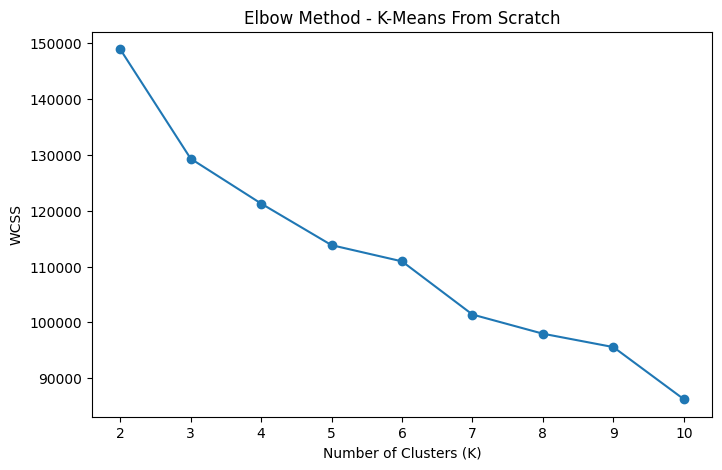

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    wcss_values,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method - K-Means From Scratch")

plt.show()

In [62]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled,kmeans.labels)
print("Silhouette Score:", score)

Silhouette Score: 0.3165669206166897


In [63]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

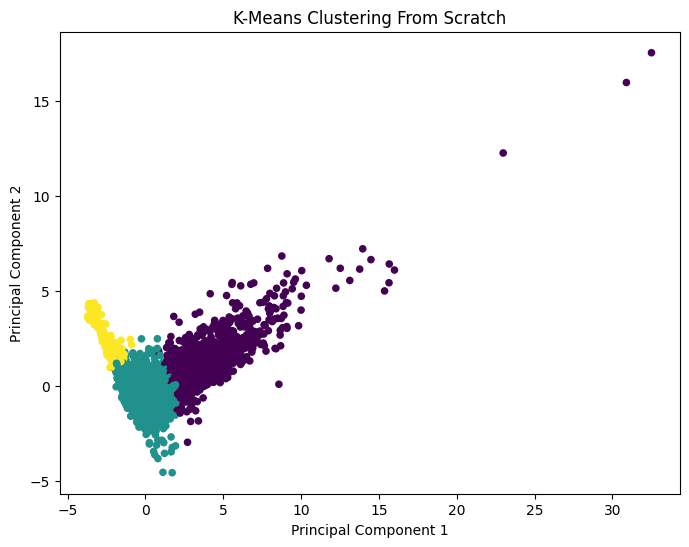

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans.labels,
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering From Scratch")

plt.show()

#K-Medoid Clustering

In [65]:
# Taking manageable sample for K-Medoids
np.random.seed(42)
sample_size = 2000
indices = np.random.choice(len(X_scaled),sample_size,replace=False)
X_medoid = X_scaled[indices]

print("K-Medoids data shape:", X_medoid.shape)

K-Medoids data shape: (2000, 14)


In [66]:
class KMedoidsScratch:

    def __init__(self, k=3, max_iter=20):
        self.k = k
        self.max_iter = max_iter
        self.medoids = None
        self.labels = None

    def fit(self, X):

        n = len(X)

        #  Choose random medoids

        medoid_indices = list(
            np.random.choice(
                n,
                self.k,
                replace=False
            )
        )

        for iteration in range(self.max_iter):

            # Step 2: Assign every point to nearest medoid

            distances = np.zeros((n, self.k))

            for i in range(self.k):

                distances[:, i] = np.linalg.norm(
                    X - X[medoid_indices[i]],
                    axis=1
                )

            labels = np.argmin(
                distances,
                axis=1
            )

            # Step 3: Find new medoid for each cluster

            new_medoids = []

            for cluster in range(self.k):

                cluster_indices = np.where(
                    labels == cluster
                )[0]

                # Empty cluster
                if len(cluster_indices) == 0:
                    new_medoids.append(
                        medoid_indices[cluster]
                    )
                    continue

                best_medoid = cluster_indices[0]
                best_cost = float('inf')

                # Try every point in cluster
                for candidate in cluster_indices:
                    cost = 0
                    for other in cluster_indices:
                        distance = np.linalg.norm(
                            X[candidate] - X[other]
                        )
                        cost += distance

                    if cost < best_cost:
                        best_cost = cost
                        best_medoid = candidate
                new_medoids.append(best_medoid)

            # Step 4: Check convergence

            if new_medoids == medoid_indices:

                print(
                    "Converged at iteration:",
                    iteration + 1
                )

                break
            medoid_indices = new_medoids
        self.medoids = medoid_indices
        self.labels = labels
        return self

    def predict(self, X):
        distances = np.zeros(
            (len(X), self.k)
        )
        for i in range(self.k):
            distances[:, i] = np.linalg.norm(
                X - self.X[self.medoids[i]],
                axis=1
            )
        return np.argmin(
            distances,
            axis=1
        )

In [67]:
kmedoids = KMedoidsScratch(k=3,max_iter=20)
kmedoids.fit(X_medoid)

Converged at iteration: 4


In [68]:
labels_kmedoids = kmedoids.labels

print("Cluster assignments:")
print(labels_kmedoids)

Cluster assignments:
[1 0 1 ... 0 1 0]


In [69]:
unique, counts = np.unique(
    labels_kmedoids,
    return_counts=True
)

for cluster, count in zip(unique, counts):

    print(
        "Cluster",
        cluster,
        ":",
        count,
        "customers"
    )

Cluster 0 : 339 customers
Cluster 1 : 1489 customers
Cluster 2 : 172 customers


In [70]:
print("Medoid indices:")
print(kmedoids.medoids)
print("\nMedoid points:")

for i in kmedoids.medoids:
    print(X_medoid[i])

Medoid indices:
[np.int64(672), np.int64(1032), np.int64(337)]

Medoid points:
[ 2.01250431  0.40762346  1.17819516  0.14525897  1.19775356  0.92836312
 -0.41235474 -0.60585353 -0.26210632 -0.30882137 -0.13607828 -0.20795193
 -0.06136354 -0.76262903]
[-0.39593771 -0.33839427 -0.3964779  -0.24493051 -0.26378439 -0.11557475
 -0.26126052 -0.553196   -0.31717784 -0.30882137 -0.13607828 -0.20795193
 -0.06136354 -0.01728851]
[-0.69699296 -0.4571914  -0.3964779  -0.24493051 -0.66851798 -0.62434752
  3.66718879  3.22931559 -0.31717784 -0.30882137 -0.13607828 -0.20795193
 -0.06136354 -0.26573535]


In [71]:
score = silhouette_score(
    X_medoid,
    labels_kmedoids
)

print("K-Medoids Silhouette Score:", score)

K-Medoids Silhouette Score: 0.30437821228738027


In [72]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_medoid,
    labels_kmedoids
)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 1.5710544803437596


#DBSCAN Clustering

In [73]:
class DBSCANScratch:

    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    # Euclidean distance
    def distance(self, p1, p2):

        return np.sqrt(
            np.sum((p1 - p2) ** 2)
        )

    # Find all points within eps distance
    def get_neighbors(self, X, point_index):

        neighbors = []

        for i in range(len(X)):

            dist = self.distance(
                X[point_index],
                X[i]
            )

            if dist <= self.eps:
                neighbors.append(i)

        return neighbors

    def fit(self, X):

        n = len(X)

        # -1 means unvisited
        # 0 means noise initially
        labels = np.full(n, -1)

        cluster_id = 0

        for point in range(n):

            # Already processed
            if labels[point] != -1:
                continue

            # Find neighbors
            neighbors = self.get_neighbors(
                X,
                point
            )

            # Not enough neighbors -> mark as noise
            if len(neighbors) < self.min_samples:

                labels[point] = 0

                continue

            # New cluster
            cluster_id += 1

            labels[point] = cluster_id

            # Expand cluster
            seeds = neighbors.copy()

            i = 0

            while i < len(seeds):

                current_point = seeds[i]

                # If previously marked noise,it can become a border point
                if labels[current_point] == 0:

                    labels[current_point] = cluster_id

                # If already assigned,don't process again
                if labels[current_point] != -1:

                    i += 1
                    continue

                labels[current_point] = cluster_id

                # Find neighbors of current point
                current_neighbors = self.get_neighbors(
                    X,
                    current_point
                )

                # If current point is a core point, add its neighbors
                if len(current_neighbors) >= self.min_samples:

                    for neighbor in current_neighbors:

                        if neighbor not in seeds:

                            seeds.append(neighbor)

                i += 1

        self.labels = labels

        return self

In [ ]:
dbscan = DBSCANScratch(
    eps=1.5,
    min_samples=5
)

dbscan.fit(X_scaled)

labels_dbscan = dbscan.labels

In [ ]:
print("Labels:")
print(labels_dbscan)

In [ ]:
unique, counts = np.unique(
    labels_dbscan,
    return_counts=True
)

for label, count in zip(unique, counts):

    if label == 0:
        print("Noise:",count)
    else:
        print( "Cluster",label, ":",count,"points")

In [ ]:
mask = labels_dbscan != 0

X_no_noise = X_scaled[mask]
labels_no_noise = labels_dbscan[mask]

if len(np.unique(labels_no_noise)) > 1:

    score = silhouette_score(
        X_no_noise,
        labels_no_noise
    )

    print(
        "DBSCAN Silhouette Score:",
        score
    )

else:

    print(
        "Not enough clusters for Silhouette Score"
    )

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering From Scratch")

plt.show()

In [ ]:
for eps in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:

    dbscan = DBSCANScratch(
        eps=eps,
        min_samples=5
    )

    dbscan.fit(X_scaled)

    labels = dbscan.labels

    clusters = len(
        set(labels) - {0}
    )

    noise = np.sum(
        labels == 0
    )

    print(
        "eps =", eps,
        "| clusters =", clusters,
        "| noise =", noise
    )

#Hierarchical Clustering